# Notebook for PlatoSim paper (2023)

This notebook is used to generate all input plots shown in the PlatoSim3 paper.

Sources:

https://lscsoft.docs.ligo.org/ligo.skymap/plot/allsky.html#

https://matplotlib.org/stable/gallery/lines_bars_and_markers/scatter_with_legend.html

https://stackoverflow.com/questions/43812911/adding-second-legend-to-scatter-plot

### Setup notebook

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib notebook

### Imports

In [2]:
import os
import h5py
import scipy
import numpy as np
import pandas as pd
from tqdm import tqdm 

from matplotlib import pyplot as plt
import matplotlib.colors  as colors
import matplotlib.patches as patches
from mpl_toolkits.axes_grid1 import make_axes_locatable

from astropy.io import fits
from astropy import units as u
from astropy.coordinates import SkyCoord

from scipy.signal import periodogram
from scipy.ndimage import median_filter
from scipy.interpolate import interp2d

import transitleastsquares as tls

# PlatoSim
import platosim.referenceFrames as rf
import platosim.plot            as pt
import platosim.utilities       as ut
from platosim.simulation   import Simulation
from platosim.simfile      import SimFile
from platosim.lightcurve   import LightCurve
from platosim.validation import switchOffAllEffects
from platosim.matplotlibrc import setup_paper
setup_paper()

# Constants
day = 86400

---
## Fig. 1 - PLATO LOPS1
---

<IPython.core.display.Javascript object>


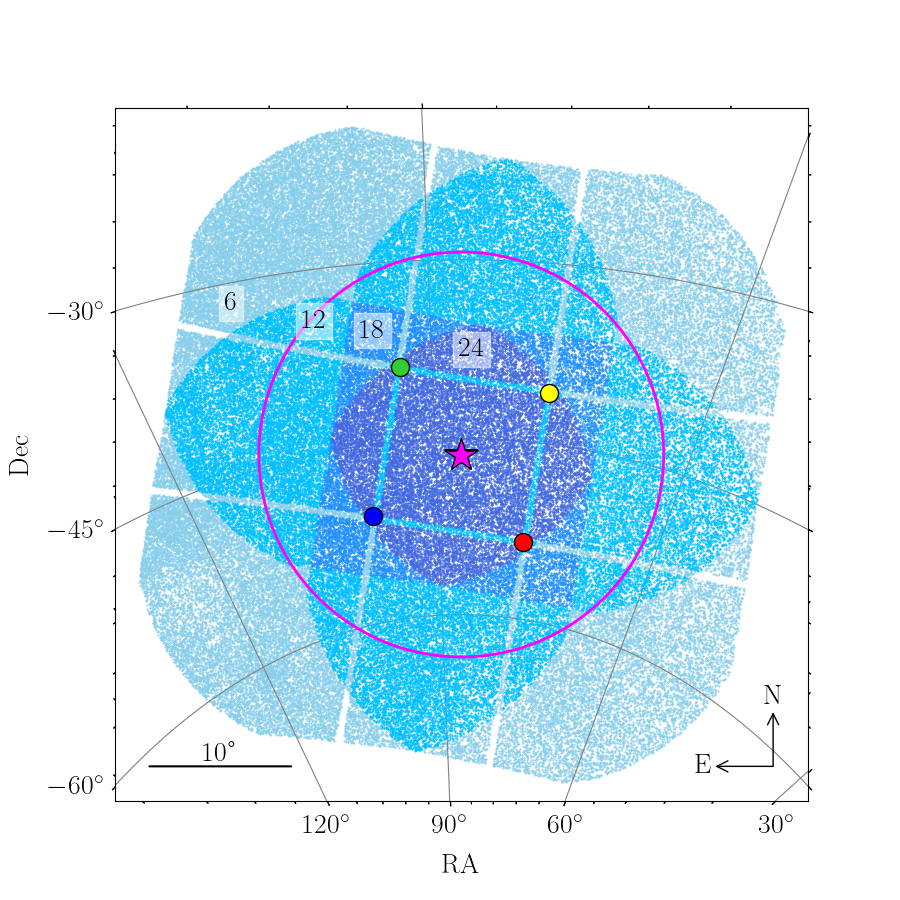

In [3]:
# Plot overall figure
fig, ax = pt.plotPlatoFOV('SPF', fs=20, system='icrs', showGroups=True, showLegend=False)

# Plot N-CAM visibility
box1 = fig.text(0.250, 0.655, '6',  fontsize=20)
box2 = fig.text(0.335, 0.636, '12', fontsize=20)
box3 = fig.text(0.400, 0.625, '18', fontsize=20)
box4 = fig.text(0.510, 0.604, '24', fontsize=20)

# Plot white boxes below
box1.set_bbox(dict(facecolor='w', alpha=0.5, edgecolor='w'))
box2.set_bbox(dict(facecolor='w', alpha=0.5, edgecolor='w'))
box3.set_bbox(dict(facecolor='w', alpha=0.5, edgecolor='w'))
box4.set_bbox(dict(facecolor='w', alpha=0.5, edgecolor='w'))

plt.show()

# Save figure
fig.savefig('PlatoFOV.png', bbox_inches='tight', dpi=200)

---
## Fig. 2 - Spectral Response curve
---

In [4]:
# First we download the passbands
odir = os.getenv("PLATO_PROJECT_HOME") + "/inputfiles"
ut.downloadFromFTP('passband_tess.txt',   odir, server='plato')
ut.downloadFromFTP('passband_plato.txt',  odir, server='plato')
ut.downloadFromFTP('passband_cheops.txt', odir, server='plato')
ut.downloadFromFTP('passband_kepler.txt', odir, server='plato')

In [5]:
grid_no = 1000

# Import PLATO passband
df_plato  = pd.read_csv(f"{odir}/passband_plato.txt", comment='#')                                                                                                                
wvl_plato = df_plato.wavelength  # [nm]                                                                                                                
tra_plato = df_plato.passband    # Absolute
# Normalize passband
tra_plato /= tra_plato.max()
wvl_int_plato  = np.linspace(wvl_plato.iloc[0], wvl_plato.iloc[-1], grid_no)                                                                                                                                         
passband_plato = scipy.interpolate.make_interp_spline(wvl_plato, tra_plato, k=3)                                                                                                                                             
tran_int_plato = passband_plato(wvl_int_plato)

# Import TESS passband
df_tess  = pd.read_csv(f"{odir}/passband_tess.txt", comment='#')                                                                                                                
wvl_tess = df_tess.wavelength  # [nm]                                                                                                                
tra_tess = df_tess.passband    # Absolute                                                                                                             
wvl_int_tess  = np.linspace(wvl_tess.iloc[0], wvl_tess.iloc[-1], grid_no)                                                                                                                                         
passband_tess = scipy.interpolate.make_interp_spline(wvl_tess, tra_tess, k=3)                                                                                                                                             
tran_int_tess = passband_tess(wvl_int_tess) 

# Import CHEOPS passband
df_cheops  = pd.read_csv(f"{odir}/passband_cheops.txt", comment='#')                                                                                                                
wvl_cheops = df_cheops.wavelength  # [nm]                                                                                                                
tra_cheops = df_cheops.passband / np.max(df_cheops.passband)    # Absolute                                                                                                             
wvl_int_cheops  = np.linspace(wvl_cheops.iloc[0], wvl_cheops.iloc[-1], grid_no)                                                                                                                                         
passband_cheops = scipy.interpolate.make_interp_spline(wvl_cheops, tra_cheops, k=3)                                                                                                                                             
tran_int_cheops = passband_cheops(wvl_int_cheops) 

# Import Kepler passband                                                                                                                                                                                                                                                                                                                                                                                          
df_kepler  = pd.read_csv(f"{odir}/passband_kepler.txt", comment='#')                                                                                                                
wvl_kepler = df_kepler.iloc[:,0]   # [nm]                                                                                                                
tra_kepler = df_kepler.iloc[:,1]   # Absolute                                                                                                                    
wvl_int_kepler  = np.linspace(wvl_kepler.iloc[0], wvl_kepler.iloc[-1], grid_no)                                                                                                                                   
passband_kepler = scipy.interpolate.make_interp_spline(wvl_kepler, tra_kepler, k=3)                                                                                                                                      
tran_int_kepler = passband_kepler(wvl_int_kepler) 

<IPython.core.display.Javascript object>


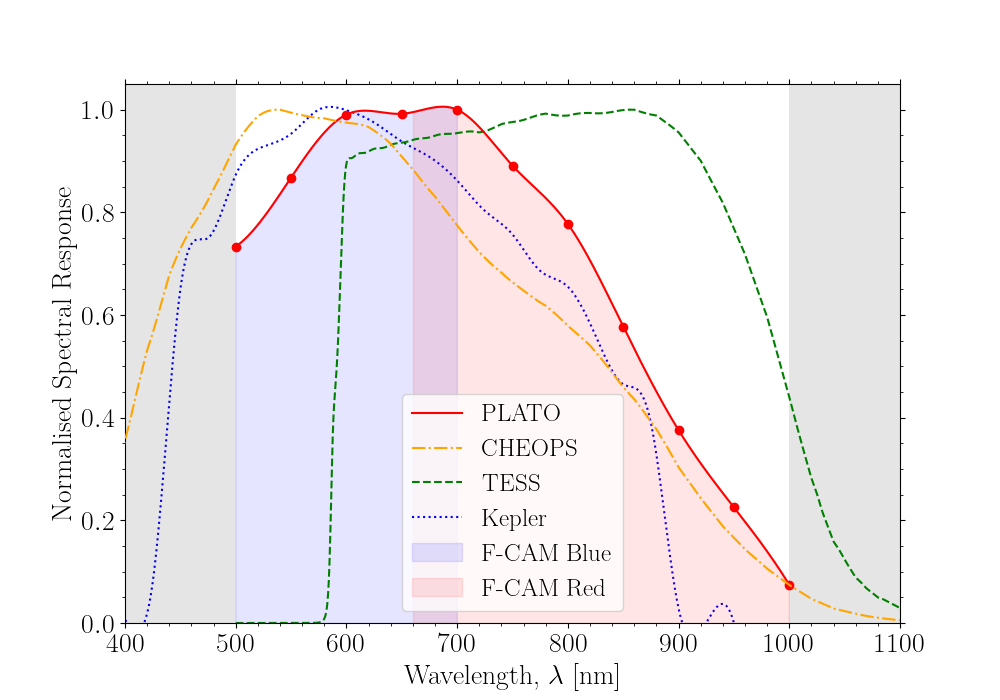

In [6]:
# Create the plot                                                                                                                                                                                                                                                                                                                                                                                              
fig, ax = plt.subplots(1, 1, figsize=(10, 7))                                                                                                                                                   
                                                                                                                                                                                                            
# Response functions:
ax.plot(wvl_plato,  tra_plato, 'ro') 
ax.plot(wvl_int_plato,  tran_int_plato,  'r-',  label='PLATO',  zorder=3) 
ax.plot(wvl_int_cheops, tran_int_cheops, '-.',  label='CHEOPS', zorder=3, c='orange') 
ax.plot(wvl_int_tess,   tran_int_tess,   'g--', label='TESS',   zorder=2)                                                                                                                                        
ax.plot(wvl_int_kepler, tran_int_kepler, 'b:',  label='Kepler', zorder=1)  
ax.axvspan(400, 500, color='k', alpha=0.1, lw=0)
ax.axvspan(1000, 1100, color='k', alpha=0.1, lw=0)

dex_max_blue = np.argmin(np.abs(wvl_int_plato - 700))
dex_max_red  = np.argmin(np.abs(wvl_int_plato - 660))
ax.fill_between(wvl_int_plato[0:dex_max_blue], tran_int_plato[0:dex_max_blue], color='blue', alpha=.1, label='F-CAM Blue')
ax.fill_between(wvl_int_plato[dex_max_red:-1], tran_int_plato[dex_max_red:-1], color='red',  alpha=.1, label='F-CAM Red')

ax.set_xlabel(r'Wavelength, $\lambda$ [nm]')                                                                                                                                                          
ax.set_ylabel(r'Normalised Spectral Response')                                                                                                                                             
ax.set_xlim(400, 1100)
ax.set_ylim(0, 1.05)
ax.legend()
plt.show()

# Save figure
fig.savefig('passbands.png', bbox_inches='tight', dpi=300)

---
## Fig. 3 - CCD subfields
---

In [ ]:
# Initialise PlatoSim (we reuse the inputfile.yaml)
outputFileName = "output_subfield"
sim = Simulation(outputFileName, outputDir=os.getcwd())

# Obs parameters
sim["ObservingParameters/NumExposures"] = 1
# sim["Platform/SolarPanelOrientation"] = 0

# Sky parameters (auto background)
sim["Sky/SkyBackground/UseConstantSkyBackground"] = 'yes'
sim["Sky/SkyBackground/BackgroundValue"]          = -1 
sim["Sky/Cosmics/CosmicHitRate"] = 10

# Subfield
# rows, cols = 1000, 900
rows, cols = 1500, 800
sim["SubField/NumColumns"]      = 400
sim["SubField/NumRows"]         = 400
sim["SubField/ZeroPointColumn"] = cols
sim["SubField/ZeroPointRow"]    = rows

# Run simulation
simfile0 = sim.run(removeOutputFile=True)

In [ ]:
# Show image
f0 = SimFile(outputFileName + ".hdf5")
fig, ax = f0.showImage(0, clipPercentile=0.9, figsize=(10,10), colorMap="cubehelix",
                      showStarPositions=False, showStarIDs=True, useTitle=False,
                      fontSize=35)
# Save figure
fig.savefig('subfield400x400pix.png', bbox_inches='tight', dpi=200)

In [ ]:
# Find target from ,catalogue of Image
cat = simfile0.getStarCoordinates(0)
starID = 10
rowStar = int(cat[1][starID])
colStar = int(cat[2][starID])
fluxStar = int(cat[-1][starID])
rowStar, colStar

In [ ]:
# Initialise PlatoSim
outputFile = "output_imagette"
sim = Simulation(outputFile, outputDir=os.getcwd())

# Observation
sim["ObservingParameters/NumExposures"] = 1

# Sky
sim["Sky/SkyBackground/UseConstantSkyBackground"] = 'yes'
sim["Sky/SkyBackground/BackgroundValue"]          = -1 
sim["Sky/Cosmics/CosmicHitRate"] = 10

# Subfield
sim["SubField/NumColumns"]      = 6
sim["SubField/NumRows"]         = 6
sim["SubField/ZeroPointColumn"] = cols + colStar - 3
sim["SubField/ZeroPointRow"]    = rows + rowStar - 3

# Control HDF5
sim["ControlHDF5Content/WriteStarPositions"]     = True
sim["ControlHDF5Content/WriteDiffusedPSF"]       = True
sim["ControlHDF5Content/WriteHighResolutionPSF"] = True

# Run simulation
simfile = sim.run(removeOutputFile=True)

In [ ]:
# Show image
f = SimFile(outputFile + ".hdf5")
fig, ax = f.showImage(0, figsize=(10,10), 
                      colorBar=True, imgScale="auto", colorMap="cubehelix",
                      showStarPositions="PIC", showStarIDs=False, useTitle=False,
                      showGrid=True, fontSize=30, tarMarkerSize=500) 

# # Save figure
fig.savefig('subfield6x6pix.png', bbox_inches='tight', dpi=200)

# Print the star magnitude used
f.getStarCatalog()[3]

---
## Fig. 8 - Jitter comparison: Prime vs. Red noise
---

In [ ]:
# Load Prime
path = "/lhome/nicholas/Nextcloud/Platoman/Models/Jitter/Prime2020jan"
df = pd.read_csv(f'{path}/01_PLATO_PDR_FPM_02_longrun_APE.csv', delimiter=';', 
                 names=['t', 'x', 'y', 'z'], skiprows=[0,1])

# Let time series start at zero seconds
df['t'] -= df['t'].iloc[0]

# Convert angles from rad -> arcsec
for n in ['x', 'y', 'z']:
    df[n] = df[n] * 206265. 
    
df.head()

In [ ]:
# Load simulated PlatoSim red noise jitter
f = h5py.File(f"{os.getcwd()}/redNoiseJitter8Hz.hdf5", "r")
x = f['ACS/Yaw'][:]

In [ ]:
# Compute PSD for Prime data
f_prime, psd_prime = periodogram(df["x"], 8, scaling='density')
f_prime   *= 1e6  # [muHz]
psd_prime *= 1e6  # [ppm^2/muHz]

# Compute PSF for PlatoSim red noise
f_red, psd_red = periodogram(x, 8, scaling='density')
f_red   *= 1e6  # [muHz]
psd_red *= 1e6  # [ppm^2/muHz]

# Median filters of 1 min
n = int(60 / 0.125)
psd_prime_med = scipy.ndimage.median_filter(psd_prime, n)
psd_red_med   = scipy.ndimage.median_filter(psd_red,   n)

In [ ]:
# Old figure with OHB jitter included
fig, ax = plt.subplots(2, 1, figsize=(10,9))

ax[0].plot(f_red, psd_red,         "-", c='tomato', label="Red noise model", lw=0.8)
ax[0].plot(f_red, psd_red_med,     "k-", label="1 min median")
ax[1].plot(f_prime, psd_prime,     "-", c='royalblue', label="Dynamical model", lw=0.8)
ax[1].plot(f_prime, psd_prime_med, "k-", label="1 min median")

for i in range(2):
    ax[i].set_xlim(1e2, f_prime.max())
    ax[i].set_ylim(1e-7, 1e6)
    ax[i].set_xscale('log')
    ax[i].set_yscale('log')

fig.text(0.50, 0.04, r"Frequency, $\nu$ [$\mu$Hz]",   ha="center")
fig.text(0.02, 0.50, r"PSD [ppm$^2$ $\mu$Hz$^{-1}$]", va="center", rotation="vertical")
ax[0].legend()
ax[1].legend()
plt.show()

# Save figure
fig.savefig('jitter.png', bbox_inches='tight', dpi=200)

---
## Fig. 9 - Distortion
---

In [ ]:
# Load Zemax PSF
f = h5py.File(os.getenv("PLATO_PROJECT_HOME")+'/inputfiles/PSF_Focus_0mu.hdf5', 'r')
coorUnd = f["Coordinates map"]["Undistorted"]
coorDis = f["Coordinates map"]["Distorted"]

In [ ]:
# Select data
xund   = coorUnd["x"][:]
yund   = coorUnd["y"][:]
xzemax = coorDis["x"][:]
yzemax = coorDis["y"][:]

# We create a grid and select points from this (8.8mm -> 1deg)
x = np.arange(1.3, 85, 8.8)
y = np.arange(1.3, 85, 8.8)

xx, yy = np.meshgrid(x,y)
coords = np.array((xx.ravel(), yy.ravel())).T

# Find indices that matches in undistorted grid point best
dex = []
for i in range(len(coords)):
    r = np.sqrt( (xund-coords[i,0])**2 + (yund-coords[i,1])**2 )
    dex.append(np.argmin(r))
xund   = np.array([xund[i] for i in dex])
yund   = np.array([yund[i] for i in dex])
xzemax = np.array([xzemax[i] for i in dex])
yzemax = np.array([yzemax[i] for i in dex])

# Calculate distortion using the Wang model for analytic PSFs
coeff = [0.32419,  0.0232909,  0.407979, 0.00022463, 0.000217599, 0.000381958, 0.000963902]
focalLength = 247.52
xwang, ywang = rf.undistortedToDistortedFocalPlaneCoordinates(xund, yund, coeff, focalLength)

# For plotting FOV limit
fov_max = np.deg2rad(18.8908)
fov_max_mm = rf.focalPlaneCoordinatesFromGnomonicRadialDistance(fov_max, focalLength)[0]

# Remove extra data at deges
rm = [39, 49, 58, 59, 67, 68, 69, 76, 77, 78, 79, 85, 86, 87, 88, 89, 93, 94, 95, 96, 97, 98, 99]
xund = np.delete(xund, rm) 
yund = np.delete(yund, rm) 
xwang = np.delete(xwang, rm) 
ywang = np.delete(ywang, rm) 
xzemax = np.delete(xzemax, rm) 
yzemax = np.delete(yzemax, rm) 

# Find the radial distance from OA for data
alpha = np.rad2deg([rf.gnomonicRadialDistanceFromOpticalAxis(xund[i], yund[i], focalLength) 
                    for i in range(len(xund))])

In [ ]:
# Plot image
fig, ax = plt.subplots(1, 2, figsize=(11,5))

# Plot CCD and FOV footprint
ax[0].add_patch(patches.Rectangle((1.3, 1.3), 82.48-1.3, 82.48-1.3, edgecolor='navy', facecolor='whitesmoke', lw=1.5, label="CCD"))
ax[0].add_patch(patches.Circle((0, 0), fov_max_mm, color='darkorange', ls="--", lw=1.5, fill=False, label="FOV"))
ax[0].scatter(xund,   yund,   s=55,  c="k", edgecolor='w', marker="o", label="Undistorted",      zorder=3)
ax[0].scatter(xwang,  ywang,  s=125, c="r", edgecolor='w', marker="d", label="Wang model",  zorder=2)
for i in range(len(xund)):
    ax[0].plot([xund[i], xwang[i]], [yund[i], ywang[i]], 'k-', zorder=2)

# Plot residuals between Wang / Zemax
ax[1].hlines(0, -0.1, 2.5, color='k', linestyle=':', zorder=0)    
ax[1].vlines(0, -0.1, 2.5, color='k', linestyle=':', zorder=0)    
im = ax[1].scatter(xwang-xzemax, ywang-yzemax, s=50, c=alpha, cmap="jet", edgecolor='k', marker="o", 
                   label="Zemax model", zorder=1)
# Set colorbar
cbar = fig.colorbar(im, extend='max', shrink=1.0, pad=0.02, ticks=[0.5,3,6,9,12,15,18])
cbar.set_label(r"Radial distance from OA, $\vartheta$ [$^{\circ}$]", labelpad=0)
# cbar.ax.tick_params(labelsize=fontSize)

# subplot 0
ax[0].set_xlabel(r"Focal plane $x$ [mm]")
ax[0].set_ylabel(r"Focal plane $y$ [mm]")
ax[0].set_aspect('equal', 'box')
ax[0].set_xlim(0, 82.48+1.4)
ax[0].set_ylim(0, 82.48+1.4)
ax[0].legend(fontsize=18, ncols=4, bbox_to_anchor=(-0.02, 1.02))

# subplot 0
ax[1].set_xlabel(r"$x_{\rm wang} - x_{\rm zemax}$ [mm]")
ax[1].set_ylabel(r"$y_{\rm wang} - y_{\rm zemax}$ [mm]")
ax[1].set_aspect('equal', 'box')
ax[1].set_xlim(-0.01, 0.18)
ax[1].set_ylim(-0.01, 0.25)

# Save figure
fig.savefig('distortion.png', bbox_inches='tight', dpi=200);

---
## Fig. 10 - Throughput map
---

In [ ]:
# This is a long simulation (~30 min)! 
exp = 1
outputFile = "output_TM"
sim = Simulation(outputFile, outputDir=os.getcwd())

In [ ]:
# Observation
sim["ObservingParameters/BeginExposureNr"] = exp
sim["ObservingParameters/NumExposures"]    = 1

# Sky
sim["Sky/SkyBackground/UseConstantSkyBackground"] = True
sim["Sky/SkyBackground/BackgroundValue"]          = -1  # Auto background
sim["Sky/Cosmics/CosmicHitRate"]                  = 0

# Subfield
sim["SubField/NumColumns"]      = 4510
sim["SubField/NumRows"]         = 4510
sim["SubField/ZeroPointColumn"] = 0
sim["SubField/ZeroPointRow"]    = 0

# Save to HDF5
sim["ControlHDF5Content/WriteTransmissionEfficiency"] = True

# Run simulation
simFile = sim.run(removeOutputFile=True)

In [ ]:
# Load file
f = SimFile(outputFile + ".hdf5")
tm = f.getThroughputMap(exp)
tm *= 100 * np.ones_like(tm)

# Get constants
pixelSize   = f.getInputParameter("CCD", "PixelSize")
focalLength = f.getInputParameter("Camera/FocalLength", "ConstantValue") * 1e3
ccdZeroPointX = sim['CCDPositions/OriginOffsetX'][0]  # [mm]
ccdZeroPointY = sim['CCDPositions/OriginOffsetX'][0]  # [mm]
distortionCoefficients = sim['Camera/FieldDistortion/ConstantCoefficients']

# Calculate diagonal offset betwee FP origo and CCD origo [deg]
alpha_offset = np.rad2deg(rf.gnomonicRadialDistanceFromOpticalAxis(ccdZeroPointX, ccdZeroPointY, focalLength))

In [ ]:
# Load file
f = SimFile(outputFile + ".hdf5")
tm = f.getThroughputMap(exp)
tm *= 100 * np.ones_like(tm)

# Get constants
pixelSize   = f.getInputParameter("CCD", "PixelSize")
focalLength = f.getInputParameter("Camera/FocalLength", "ConstantValue") * 1e3
ccdZeroPointX = sim['CCDPositions/OriginOffsetX'][0]  # [mm]
ccdZeroPointY = sim['CCDPositions/OriginOffsetX'][0]  # [mm]
distortionCoefficients = sim['Camera/FieldDistortion/ConstantCoefficients']

# Calculate diagonal offset betwee FP origo and CCD origo [deg]
alpha_offset = np.rad2deg(rf.gnomonicRadialDistanceFromOpticalAxis(ccdZeroPointX, ccdZeroPointY, focalLength))

# Radial flux cut-off from stray light mask (undistorted and distorted)
alpha_max_und = np.deg2rad(18.9)
alpha_max_exp = np.deg2rad(20.0)

xFP_max_und, yFP_max_und = rf.focalPlaneCoordinatesFromGnomonicRadialDistance(alpha_max_und, focalLength, inPlaneRotation=45.)
xFP_max_dis, yFP_max_dis = rf.undistortedToDistortedFocalPlaneCoordinates(xFP_max_und, yFP_max_und, distortionCoefficients, focalLength)
xFP_max_exp, yFP_max_exp = rf.focalPlaneCoordinatesFromGnomonicRadialDistance(alpha_max_exp, focalLength, inPlaneRotation=45.)

xCCD_max_und, yCCD_max_und = rf.focalPlaneToPixelCoordinates(xFP_max_und, yFP_max_und, pixelSize, 
                                                             ccdZeroPointX=ccdZeroPointX, 
                                                             ccdZeroPointY=ccdZeroPointY, 
                                                             CCDangle=0)
xCCD_max_dis, yCCD_max_dis = rf.focalPlaneToPixelCoordinates(xFP_max_dis, yFP_max_dis, pixelSize, 
                                                             ccdZeroPointX=ccdZeroPointX, 
                                                             ccdZeroPointY=ccdZeroPointY, 
                                                             CCDangle=0)
xCCD_max_exp, yCCD_max_exp = rf.focalPlaneToPixelCoordinates(xFP_max_exp, yFP_max_exp, pixelSize, 
                                                             ccdZeroPointX=ccdZeroPointX, 
                                                             ccdZeroPointY=ccdZeroPointY, 
                                                             CCDangle=0)
r_max_und = np.sqrt(xCCD_max_und**2 + yCCD_max_und**2)
r_max_dis = np.sqrt(xCCD_max_dis**2 + yCCD_max_dis**2)
r_max_exp = np.sqrt(xCCD_max_exp**2 + yCCD_max_exp**2)

# Find alpha_max in pixels
alpha = np.arange(0,22,2)
xFP, yFP = rf.focalPlaneCoordinatesFromGnomonicRadialDistance(np.deg2rad(alpha), focalLength, 
                                                              inPlaneRotation=np.deg2rad(45))
xCCD, yCCD = rf.focalPlaneToPixelCoordinates(xFP, yFP, pixelSize, 
                                             ccdZeroPointX=ccdZeroPointX, ccdZeroPointY=ccdZeroPointY, CCDangle=0)

# Revert the inclusion of the QE
tm0 = tm / (sim["CCD/QuantumEfficiency/MeanQuantumEfficiency"] * sim["CCD/QuantumEfficiency/MeanAngleDependency"])
tm0 = tm

In [ ]:
# a = np.rad2deg(rf.gnomonicRadialDistanceFromOpticalAxis(2.857, 2.857, focalLength))
r_max_dis

In [ ]:
# Create plot
fig, ax = plt.subplots(1,1, figsize=(10,10))

# Set zero throughput to different color
tm1 = np.ma.masked_where(tm0 == 0, tm0)
cmap = plt.cm.cubehelix
cmap.set_bad(color='#303030')

im = ax.imshow(tm1, interpolation='nearest', extent=[0, 4510, 0, 4510], cmap=cmap, origin="lower",
               vmin=np.sort(np.unique(tm0))[1], vmax=np.max(tm0))

cbar = fig.colorbar(im, extend='max', shrink=0.84, pad=0.015)                     
cbar.set_label(r"Optical throughput, $(T \cdot Q)$ [\%]", labelpad=3)                                    
cbar.ax.tick_params()

# Plot circle 
ax.add_patch(patches.Circle((0, 0), r_max_und, color='r', ls="--", lw=2.0, fill=False, label="Undist."))
ax.add_patch(patches.Circle((0, 0), r_max_dis, color='r', ls=":",  lw=2.5, fill=False, label="Distort."))
ax.add_patch(patches.Circle((0, 0), r_max_exp, color='r', ls="-",  lw=1.5, fill=False)) #, label="Distort."))

# Plot distance indicator
ax.plot(xCCD, yCCD, "ko:", mec="w", ms=7, label=r"$\vartheta$ [$^{\circ}$]")
for i in range(1,len(alpha)): 
    
    # Change color of labels
    if i in (len(alpha)-2, len(alpha)-1): color = "w"
    else: color = "k"
        
    # Change position of labels
    if i == len(alpha)-1:
        ax.text(xCCD[i]+110, yCCD[i]-60, "{:.0f}".format(alpha[i])+r"$^{\circ}$", color=color, fontsize=21)
    else:
        ax.text(xCCD[i]+70, yCCD[i]-200, "{:.0f}".format(alpha[i])+r"$^{\circ}$", color=color, fontsize=21)
    
# Settings
ax.set_xlabel(r"Pixel column, $i$")
ax.set_ylabel(r"Pixel row, $j$")
ax.legend(loc='upper right', fontsize=17)
ax.set_xlim(0, 4510)
ax.set_ylim(0, 4510)
plt.show()

# Save figure
fig.savefig('throughput.png', bbox_inches='tight', dpi=200)

---
## Fig. 11 - PRNU
---

In [ ]:
# We use the previous simulation to plot the flat-field [%]
prnu = (f.getPRNU() - 1) * 100

# Create plot
fig, ax = plt.subplots(1,1, figsize=(9.5,9.5))

im = ax.imshow(prnu, interpolation='nearest', extent=[0,4510,0,4510], cmap="cubehelix", origin="lower")
cbar = fig.colorbar(im, extend='max', shrink=0.84, pad=0.015)                     
cbar.set_label(r"PRNU [\%]", labelpad=3)                                    
cbar.ax.tick_params()
ax.set_xlabel(r"Pixel column, $i$")
ax.set_ylabel(r"Pixel row, $j$")
# ax.set_xticks(np.arange(0, 250, 50))
# ax.set_yticks(np.arange(0, 250, 50))
plt.show()

# Save figure
fig.savefig('prnu.png', bbox_inches='tight', dpi=200)

---
## Fig. 12 - CTI for EOL
---

In [ ]:
def simCTI(sim):
    
    # Observation
    exp = int(6.5 * 365 * 24 * 60 * 60 / 25.)
    sim["ObservingParameters/BeginExposureNr"] = exp
    sim["ObservingParameters/NumExposures"]    = 1

    # Sky
    sim["Sky/SkyBackground/UseConstantSkyBackground"] = 'yes'
    sim["Sky/SkyBackground/BackgroundValue"]          = -1 
    sim["Sky/Cosmics/CosmicHitRate"] = 0

    # Subfield
    sim["SubField/NumColumns"]      = 130
    sim["SubField/NumRows"]         = 201
    sim["SubField/ZeroPointColumn"] = 2940
    sim["SubField/ZeroPointRow"]    = 3010
    
    return sim, exp


def addCbar(fig, ax, im):
    divider = make_axes_locatable(ax)
    cax = divider.new_vertical(size='7%', pad=0.1)
    fig.add_axes(cax)
    cbar = fig.colorbar(im, cax=cax, orientation='horizontal')
    cbar.ax.xaxis.set_ticks_position('top')
    cbar.ax.xaxis.set_label_position('top')

### Simple model 

In [ ]:
# Initialise PlatoSim
sim = Simulation("output_CTI_simple", outputDir=os.getcwd())

# Alter simfile
sim['CCD/CTI/Model']          = 'Simple'
sim['CCD/CTI/Simple/MeanCTE'] = 0.9999
# sim, exp = simCTI(sim)
exp = int(6.5 * 365 * 24 * 60 * 60 / 25.)
sim["ObservingParameters/BeginExposureNr"] = exp
sim["ObservingParameters/NumExposures"]    = 1
sim["Sky/Cosmics/CosmicHitRate"] = 0
sim["SubField/NumColumns"]      = 100
sim["SubField/NumRows"]         = 100
sim["SubField/ZeroPointColumn"] = 2940
sim["SubField/ZeroPointRow"]    = 3010

# Run simulation
f = sim.run(removeOutputFile=True);

In [ ]:
# Show image
fig, ax = f.showImage(exp, imgScale="auto", clip=0.5, figsize=(10,10),
                      showStarIDs=True, colorBar=True, fontSize=20,
                      colorMap="cubehelix", origin="upper")
ax.set_xlabel(r'Pixel column, $i$')
ax.set_ylabel(r'Pixel row, $j$')

# Save figure
# fig.savefig('cti.png', bbox_inches='tight', dpi=200)

### Short model

In [ ]:
# Initialise PlatoSim
sim = Simulation("output_CTI_short", outputDir=os.getcwd())

# Alter simfile
sim['CCD/CTI/Model'] = 'Short2013'
sim, exp = simCTI(sim)
sim["ControlHDF5Content/WriteTransmissionEfficiency"] = True

# Run simulation
f = sim.run(removeOutputFile=True)

In [ ]:
# Show image
# fig, ax = f.showImage(exp, imgScale="auto", clip=0.8, figsize=(10,10),
#                       showStarIDs=True, colorBar=True, fontSize=20,
#                       colorMap="cubehelix", origin="upper")
# ax.set_xlabel(r'Pixel column, $i$')
# ax.set_ylabel(r'Pixel row, $j$')

# Save figure
# fig.savefig('cti.png', bbox_inches='tight', dpi=200)

In [ ]:
f0 = SimFile("output_CTI_simple.hdf5")
f1 = SimFile("output_CTI_short.hdf5")
sigma = 0.5
# im0 = ut.imageNorm(f1.getImage(), "log", sigma=0.8)
# im1 = ut.imageNorm(f1.getImage(), "log", sigma=0.8)

fig, ax = plt.subplots(1, 2, figsize=(9,7))

# Plot image
im, norm, vmin, vmax = ut.imageClip(f0.getImage(), 'auto', sigma=sigma)
im0 = ax[0].imshow(im, norm=None, cmap='cubehelix', origin='upper')
addCbar(fig, ax[0], im0)

im, norm, vmin, vmax = ut.imageClip(f1.getImage(), 'auto', sigma=sigma)
im1 = ax[1].imshow(im, norm=None, cmap='cubehelix', origin='upper')
addCbar(fig, ax[1], im1)

ax[0].set_ylabel(r'Row pixel, $j$')
fig.text(0.5, 0.96, 'Normalised counts', ha='center')
fig.text(0.5, 0.01, r'Column pixel, $i$', ha='center')
fig.text(0.375, 0.765, r'a) Simple model',  ha='center', color='white')
fig.text(0.77, 0.765, r'b) Short model',  ha='center', color='white')

# ax[0].invert_yaxis()
ax[0].set_yticks([0, 50, 100, 150, 200])
ax[1].set_yticks([0, 50, 100, 150, 200])
ax[0].set_yticklabels([200, 150, 100, 50, 0])
ax[1].set_yticklabels([])
plt.subplots_adjust(wspace=0, hspace=0)

fig.savefig('ctiModels.png', bbox_inches='tight', dpi=200)

---
## Fig. 13 - Microscanning
---

In [ ]:
# Constants
cadence  = 25.  # [s]                                                                                                                                                                             
quarter  = 0                                                                                                                                                                                           
day = 86400.                                                                                                                                                                                            

# Download and load files
file_bc = 'microscan_spiral_8Hz_3h_BC.txt'
file_wc = 'microscan_spiral_8Hz_3h_WC_01.txt'
ut.downloadFromFTP(file_bc)
ut.downloadFromFTP(file_wc)
filename_bc = os.getenv('PLATO_PROJECT_HOME') + f'/inputfiles/{file_bc}'
filename_wc = os.getenv('PLATO_PROJECT_HOME') + f'/inputfiles/{file_wc}'

data_bc = np.loadtxt(filename_bc)
data_wc = np.loadtxt(filename_wc)
t_bc, x_bc, y_bc, z_bc = data_bc[:,0], data_bc[:,1], data_bc[:,2], data_bc[:,3]
t_wc, x_wc, y_wc, z_wc = data_wc[:,0], data_wc[:,1], data_wc[:,2], data_wc[:,3]

time_points = round(t_bc[-1] / cadence)
timeStart   = round(90. * quarter * day)                                                                                                                                                                   
timeEnd     = round(timeStart + time_points * cadence)                                                                                                                                                    
time        = np.arange(timeStart, timeEnd, cadence)

# Find points at cadence
dex_bc = [ut.findNearestIndex(t_bc, time[i]) for i in range(len(time))]
dex_wc = [ut.findNearestIndex(t_wc, time[i]) for i in range(len(time))]

In [ ]:
# Plot spiral
fig, ax = plt.subplots(1, 2, figsize=(8,4.5))

# Plots
for i in range(2):
    ax[i].axvline(x=-7.5, color='k', linestyle=':')
    ax[i].axvline(x=+7.5, color='k', linestyle=':')
    ax[i].axhline(y=-7.5, color='k', linestyle=':')
    ax[i].axhline(y=+7.5, color='k', linestyle=':')
ax[0].plot(x_bc, y_bc, 'k-')
ax[1].plot(x_wc, y_wc, 'k-')
ax[0].plot(x_bc[dex_bc], y_bc[dex_bc], 'bo', alpha=0.7, ms=4)
ax[1].plot(x_wc[dex_wc], y_wc[dex_wc], 'ro', alpha=0.7, ms=4)

# Labels
ax[0].set_title('Best case', fontsize=22)
ax[1].set_title('Worst case', fontsize=22)                                                                                                                                                                        
fig.text(0.50, -0.01, 'Yaw [arcsec]',   ha="center")
fig.text(-0.01, 0.50, 'Pitch [arcsec]', va="center", rotation=90)

# Settings
for i in range(2):
    ax[i].set_xlim(-10,10)
    ax[i].set_ylim(-10,10)
    ax[i].set_aspect('equal', 'box')
    ax[i].locator_params(axis='x', nbins=5)
    ax[i].locator_params(axis='y', nbins=5)
ax[1].yaxis.set_ticklabels([])
ax[1].xaxis.set_ticklabels(["","-5","0", "5", "10"]) 
plt.tight_layout(pad=-0)                                                                                                                                                                                      
plt.show()

# Save figure
fig.savefig('microscans.png', bbox_inches='tight', dpi=200);

---
## Fig. 14 - Photometry
---

In [ ]:
# Outputs
outputDir      = os.getcwd()
outputFileName = "output_photometry"

# Set up a Simulation object
sim = Simulation(outputFileName, outputDir=os.getcwd())

# Obs
sim["ObservingParameters/NumExposures"] = int(88*86400/25.)

# Subfield
sim["SubField/ZeroPointRow"]    = 1000
sim["SubField/ZeroPointColumn"] = 1000
sim["SubField/NumColumns"]      = 8
sim["SubField/NumRows"]         = 8

# Sky background
sim["Sky/SkyBackground/UseConstantSkyBackground"] = True
sim["Sky/SkyBackground/BackgroundValue"]          = -1

# Cosmic rays
sim["Sky/Cosmics/CosmicHitRate"]       = 10
sim["Sky/IncludeCosmicsInSubField"]    = "yes"
sim["Sky/IncludeCosmicsInSmearingMap"] = "yes"
sim["Sky/IncludeCosmicsInBiasMap"]     = "yes"   

# PSF
sim["PSF/Model"] = "AnalyticNonGaussian"

# Photometry
sim["Photometry/IncludePhotometry"]  = "yes"
sim["Photometry/MaskUpdateInterval"] = 14

# Output
sim.turnOffAllOutput()
sim["ControlHDF5Content/WritePixelMaps"]     = True                                                                             
sim["ControlHDF5Content/WriteStarPositions"] = True

In [ ]:
# Define catalogue
row = np.array([4.0]) + sim["SubField/ZeroPointRow"]
col = np.array([4.0]) + sim["SubField/ZeroPointColumn"]
mag = np.array([10.0])
ID  = [1]

# Create the catalogue file
starcatFile = os.getcwd() + "/inputfile_starcat.txt"
sim.createStarCatalogFileFromPixelCoordinates(row, col, mag, ID, starcatFile)

In [ ]:
# Create photometry file (this function automatically sets the file as well)
photometryFile = os.getcwd() + "/inputfile_photometry.txt"
sim.createPhotometryFile(ID[0], photometryFile)

In [ ]:
# Create a drift file (this function automatically sets the file as well)
driftFile = os.getcwd() + "/inputfile_drift.txt"
sim.createDriftFile(quarter=range(1,2), fileName=driftFile, model="linear", plot=True); 

In [ ]:
# Run the simulation
f = sim.run(removeOutputFile=True, executionTime=True)

In [ ]:
# First check the subfield looks good
fig, ax = f.showImage(imgScale="percentile", fontSize=20, showStarPositions="PIC",
                      colorBar=True, showGrid=True, showMaskOfStarID=ID[0])

In [ ]:
# Load light curve objects
lc = LightCurve(outputFileName + ".hdf5")

In [ ]:
# Show the light curve (mask update events are show automatically)
fig, ax = lc.plot(median_filter=1, flux_unit="e/s", legend=False, figsize=(8.5,4));
ax.set_xticks([0, 10, 20, 30, 40, 50, 60, 70, 80])
# ax.set_yticks([140000, 142000, 144000, 146000])
fig.savefig('photometry.png', bbox_inches='tight', dpi=200)